# DEF-D Fysieke Ontwerpopdracht 2 invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in (als in *PR* op GitHub en de link op Brightspace). Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 45   |  |
| :-------------|:-------------|
| Student Ebe Polman| 6581455 |
| Student Luc van der wilt| 6430589 |
| Thijs Spilt | 6540619 |
| Planning Groep: 45     |Tijdstip / Tijdspanne  |
|---|---|
| alle sanity checks af  | 12.45 |
| sensor ontwerp bedenken | 14.00 |
| sensor bouwen en kalibreren | 15:45 |
| groep aanwezig 2| Tijdspanne |
| 12.45| 1h |


## *Opdracht 1*: Sanity check 3

#### Voeg hier een foto van de schets van je plaatcondensator in. Geef daarbij ook duidelijk de waarde van $A$ en $d$ aan.
<img src="plaatcondensator schets.jpg" alt="schets student 1" width="400"/>

In [1]:
# Schrijf hier een python functie die de capaciteit van een plaatcondensator uitrekent. Zorg dat de functie
# als input de ontwerpparameters van de vlakke plaat formule accepteert (oppervlakte, afstand en diëlektrische
# constante) en als output de capaciteit van de vlakke plaat condensator met die ontwerpparameters.
# Je gaat deze formule de rest van de dag gebruiken: controleer hem goed!
import numpy as np


eps_0 = 8.854e-12
eps_air = 1
eps_pap = 2.3
A_plaat = 0.1**2
d_pap = 0.075e-3
d_karton = 1.13e-3 

def vlakkeplaat(A, d, eps_r):
    C = eps_0 * eps_r * A / d
    return C

# Optioneel: schrijf je functie zodanig dat je arrays als input kan geven en (dus) ook arrays als output.

In [2]:
# Gebruik je formule om uit te rekenen wat je verwacht dat de capaciteit van jullie vlakke plaat condensatoren
# gaat zijn.

#C = [vlakkeplaat(2.0), vlakkeplaat(4.7),vlakkeplaat(1.2)]

C_plaat = vlakkeplaat(A_plaat, d_karton, eps_pap )
print("Berekende capaciteit plaatcondensator groep 45 is", round(C_plaat,12), "F")




Berekende capaciteit plaatcondensator groep 45 is 1.8e-10 F


#### Voeg hier een foto van je plaatcondensator en van de meting op de scope in. Dus 2 foto's.
![scope meting 1](scoop.jpg)
![scope meting 2](condensator.jpg)

### Meting capaciteit
Vul onderstaande tabel in. Bij Sanity check 2 heb je afgeleid hoe je van berekende capaciteit naar berekend voltage gaat en terug. 


| Namen         | Berekende capaciteit   | Berekend Voltage | Gemeten Voltage | Gemeten capaciteit   |
|-------------|-------------:|-------------:|-------------:|-------------:|
| groep 45| 180 pf |0.9  V | 0.700 V |139 pF |

## *Opdracht 2:* Synthese.

#### Voeg hier voor een foto van je schets(en) van minimaal drie sensoren in.
![drie schetsen](schets_van_3.jpeg)


## Opdracht 3: Welke sensor gaan jullie maken?

Wij gaan een sensor maken die gewicht meet.

## Opdracht 4: Uitgewerkte schets (afmetingen!) en plot van de ontwerpgrafiek.

#### Voeg hier een foto van jullie uitgewerkte  schets van de sensor die jullie gaan maken in
![uitgewerkte schets](sensor_goede_schets.jpeg)

Text(0, 0.5, 'Capaciteit (F)')

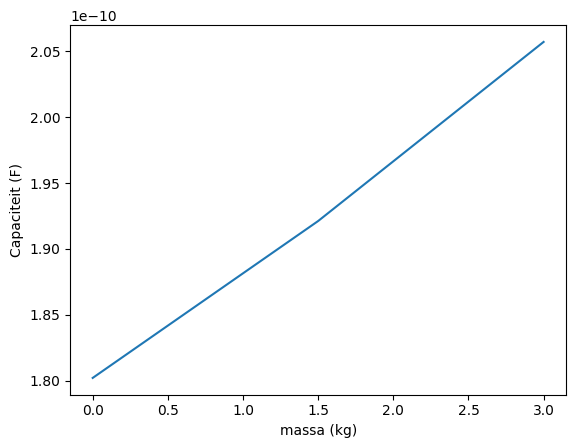

In [3]:
# We beschouwen het karton als een veer met een constante veerconstante, waardoor de capacitiet linear toe zal nemen. 
#we verwachten dat de dikte van het karton onder het gewicht van 1,5 kilo 0.07 mm afneemt =. En onder 3 kilo 0.14mm linea
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
massas_exp = np.array([0,1.5,3])

diktes = np.array([d_karton, d_karton - 7e-5, d_karton - 14e-5])

plt.plot(massas_exp, vlakkeplaat(A_plaat, diktes, eps_pap))
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")

## Opdracht 5: Invullen tabel LTSpice.

|         | Capaciteit waarde (pF)  | LTSpice berekend output Vpp (V)|
|-------------|-------------:|-------------:|
| minmale capaciteit| 130pF |0,650V |
| gemiddelde capaciteit| 150pF |0,750V |
| maximale capaciteit| 170pF | 0,850V |

## Opdracht 6: Foto's werkende opstelling.

#### Voeg hier de foto's van je sensoren in actie in.
![meting 1](wekende_opstelling_1.jpeg)
![meting 1](opstelling_1_meting.jpeg)
![meting 2](opstelling_meting_2.jpeg)
![uitkomst 2](meting_uitkomst_2.jpeg)

## Opdracht 7: Plot de kalibratiegrafiek.

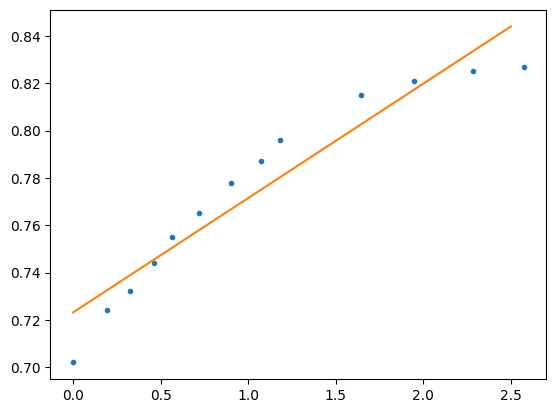

In [4]:
# Plot hier je gemeten kalibratiegrafiek en plot in dezelfde figuur ook je verwachte ontwerpgrafi
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

massas = np.array([0,0.5638,0.463,1.1806,0.7176,0.7176+0.3548,0.9032,0.1924,0.3247, 2.5748, 2.2861, 1.9465, 1.6456])
Voltages = np.array([0.702,0.755,0.744,0.796,0.765,0.787,0.778,0.724,0.732, 0.827, 0.825, 0.821,0.815])


plt.plot(massas, Voltages, ".")


Capaciteit = Voltages/(2*1000*8*np.pi*100e3)



xtst = np.linspace(0,2.5,100)

def fitfunc(x, A, B):
    return A + B * x

popt2, pcov2 = curve_fit(fitfunc, massas, Voltages)

plt.plot(xtst, fitfunc(xtst, *popt2))



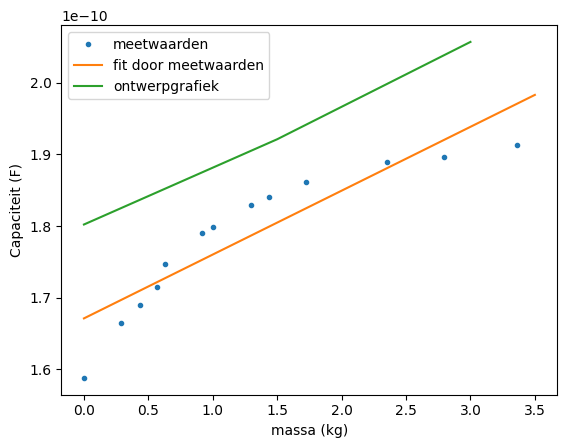

In [5]:
#MET ARDUINO

massas_ard = 1e-3*np.array([0,288.6,436.8,567.4,627.7,567.4+436.8,567.4+436.8+288.6,288.6+627.7,1438.3,288.6+1438.3,288.6+1438.3+627.7,288.6+1438.3+627.7+436.8,288.6+1438.3+627.7+436.8+567.4])

Cap_ard = 1e-12* np.array([158.8,166.4,169.0,171.5,174.7,179.8,183.0,179.0,184.1,186.1,188.9,189.6,191.3])

plt.plot(massas_ard,Cap_ard, ".", label = "meetwaarden")

xtst = np.linspace(0,3.5,100)

popt2, pcov2 = curve_fit(fitfunc, massas_ard, Cap_ard)

plt.plot(xtst, fitfunc(xtst, *popt2), label = "fit door meetwaarden")
plt.plot(massas_exp, vlakkeplaat(A_plaat, diktes, eps_pap), label = 'ontwerpgrafiek')
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()

## Opdracht 8: Vul de tekst aan.

Onze sensor kan nog verbetered worden door de volgende verbeteringen (minimaal 2):

1. Ander materiaal dan karton gebruiken waarvan de indrukking beter voorspelbaar is
2. paper clip niet in het midden, maar aan de zijkant van de bovenste plaat leggen zodat de massa beter verdeeld is. 

## Opdracht 9: Uiteindelijke ontwerp en kalibratiegrafiek.

#### Voeg hier een foto van je uiteindelijke sensor in.
![foto sensor](sensorverbeterd.jpeg)

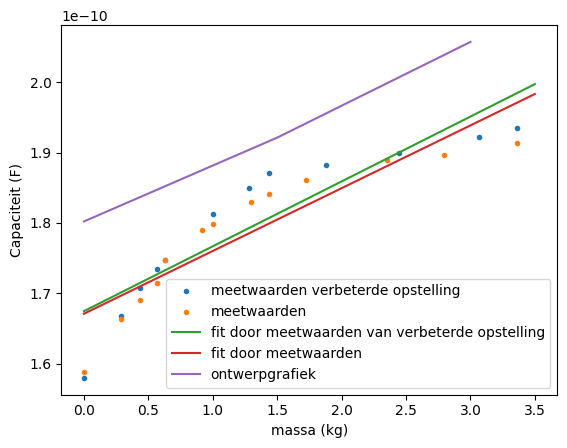

In [6]:
# Plot hier je oorspronkelijke en je uiteindelijke kalibratiegrafieken, fit daar een bijpassende lijn door
# en zet ook de verwachte ontwerpgrafiek erbij
massa_verb = 1e-3*np.array([0, 288.6,627.7,436.8,567.4,436.8+567.4,288.6+426.8+567.4,1438.3,1438.3+436.8,1438.3+436.8+567.4,1438.3+436.8+567.4+627.7,1438.3+436.8+567.4+627.7+288.6])
Cap_verb = 1e-12 * np.array([158.0, 166.8,174.7,170.7,173.4,181.2,184.9,187.1,188.2,190.0,192.2,193.5])

plt.plot(massa_verb, Cap_verb, ".", label = "meetwaarden verbeterde opstelling")

plt.plot(massas_ard,Cap_ard, ".", label = "meetwaarden")

xtst = np.linspace(0,3.5,100)




popt3, pcov3 = curve_fit(fitfunc, massa_verb, Cap_verb,  maxfev=10000)

plt.plot(xtst, fitfunc(xtst, *popt3), label = "fit door meetwaarden van verbeterde opstelling")



popt2, pcov2 = curve_fit(fitfunc, massas_ard, Cap_ard)

plt.plot(xtst, fitfunc(xtst, *popt2), label = "fit door meetwaarden")
plt.plot(massas_exp, vlakkeplaat(A_plaat, diktes, eps_pap), label = 'ontwerpgrafiek')
plt.xlabel("massa (kg)")
plt.ylabel("Capaciteit (F)")
plt.legend()
plt.show()

## Opdracht 10: Vul hieronder de conclusie in.

Uit de data bleek dat er geen lineair verband bestaat tussen de verandering in diktes van het karton en de capaciteit. Daarom is het niet correct om een lineaire fit door deze meetwaarden te doen. Omdat het echte verband buiten de scope van dit vak gaat kunnen we fysisch geen andere fitfunctie dan  een lineaire verantwoorden. Een verantwoorde fitfunctie zou de punten wel goed benaderen waardoor de sensor goed zal functioneren als weegschaal. Met onze lineaire fit moeten we echter concluderen dat de sensor niet geschikt is als weegschaal. Na de iteratie gaat de fit niet beter door de punten heen, maar ook niet slechter. Hieruit kunnen we concluderen dat de iteratie geen invloed had op de kwaliteit van de sensor. Het andere idee voor een iteratie zou waarschijnlijk wel een verbetering opleveren, maar omdat we toch geen fysisch verantwoorde fitfunctie (behalve een lineaire functie) kunnen gebruiken, zal ook deze iteratie geen effect hebben.  Daarnaast zit er een geen significant verschil tussen de ontwerpgrafiek en de kalibratiegrafiek. Het zijn namelijk allebei lineaire functies. Alleen de hoogtes van de grafieken komen niet goed overeen omdat het erg lastig is om van tevoren een goede schatting te maken van de mate van indrukking van een stukje karton onder een bepaald gewicht. De vlakke plaat formule klopt wel goed genoeg voor de sensor. Dit blijkt uit het feit dat de capaciteit vanuit de vlakke plaat formule goed overeenkomt met de daadwerkelijke capaciteit bepaald met de opstelling.

 

## Opdracht 11: Kopieer hieronder de leerdoelen.
1. Het kunnen gebruiken van de eigenschappen van een elektrische component in een ontwerpproces om een fysische grootheid te meten.
2. Kennis hebben van gedrag van elektrische componenten en meetopstellingen.
3. Onderdelen van een datasheet zoals een kalibratiegrafiek opstellen, gevoeligheid en onzekerheid beschrijven.

## Leerdoel 1

Cellen 5, 6, 8, 9, 10, 14


## Leerdoel 2

Cellen 7, 19, 24, 26, 29

## Leerdoel 3

Cellen 21, 22, 27